In [1]:
# ----------------------------------------------------
# imports
# ----------------------------------------------------
from pathlib import Path
from matplotlib.patches import Patch
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------
# configurations
# ----------------------------------------------------

RESULTS_DIR = Path("results")

parametersets = [
    "sha2-128s", "sha2-128f",
    "sha2-192s", "sha2-192f",
    "sha2-256s", "sha2-256f",
    "shake-128s", "shake-128f",
    "shake-192s", "shake-192f",
    "shake-256s", "shake-256f",
]

implementations = ["jasmin_ref", "jasmin_avx2", "c_ref", "openssl"]

actions = ["keygen", "sign", "verify"]

# ----------------------------------------------------
# separate the parts making up a parameter set,
# e.g. "sha2-128s" -> ("sha2", 128, "s")
# ----------------------------------------------------
def parse_paramset(ps):
    algo, rest = ps.split("-")
    size = int(rest[:-1])
    tradeoff = rest[-1]
    return algo, size, tradeoff

In [2]:
# ----------------------------------------------------
# load all cycle measurement benchmark data
# data structure:
# benchmark_data[impl][paramset][action] = np.array(...)
# ----------------------------------------------------

def load_cycles(filepath):
    cycles = []
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                cycles.append(int(line))
    return np.array(cycles, dtype=np.int64)

benchmark_data = {impl: {} for impl in implementations}

def trim_outliers(data, upper_percent=95.0):
    upper = np.percentile(data, upper_percent)
    return data[data <= upper]

for impl in implementations:
    for paramset in parametersets:
        for action in actions:

            filename = f"{impl}_{paramset}_{action}.txt"
            filepath = RESULTS_DIR / filename

            if not filepath.exists():
                print(f"[WARNING] Missing file: {filepath}")
                continue

            cycles = load_cycles(filepath)

            # remove extreme 5% total
            cycles = trim_outliers(cycles)

            benchmark_data.setdefault(impl, {}).setdefault(paramset, {})[action] = cycles

In [3]:

# ----------------------------------------------------
# compute left/right split violin data sets
# ----------------------------------------------------
def split_violin(ax, data_left, data_right, positions, impl_left, impl_right, width=0.8):

    vp_left = ax.violinplot(
        data_left,
        positions=positions,
        widths=width,
        showmeans=False,
        showmedians=False
    )

    vp_right = ax.violinplot(
        data_right,
        positions=positions,
        widths=width,
        showmeans=False,
        showmedians=False
    )

    # ----------------------------------------------------
    # style + clipping
    # ----------------------------------------------------
    for body in vp_left["bodies"]:
        if impl_left == "jasmin_ref":
            body.set_facecolor("tab:blue")
        elif impl_left == "jasmin_avx2":
            body.set_facecolor("tab:purple")
        elif impl_left == "c_ref":
            body.set_facecolor("tab:orange")
        elif impl_left == "openssl":
            body.set_facecolor("tab:green")
        else:
            body.set_facecolor("tab:blue")
        body.set_alpha(0.6)
        body.set_edgecolor("black")

        path = body.get_paths()[0]
        verts = path.vertices
        center = np.mean(verts[:, 0])
        verts[verts[:, 0] > center, 0] = center

    for body in vp_right["bodies"]:
        if impl_right == "jasmin_ref":
            body.set_facecolor("tab:blue")
        elif impl_right == "jasmin_avx2":
            body.set_facecolor("tab:purple")
        elif impl_right == "c_ref":
            body.set_facecolor("tab:orange")
        elif impl_right == "openssl":
            body.set_facecolor("tab:green")
        else:
            body.set_facecolor("tab:orange")
        body.set_alpha(0.6)
        body.set_edgecolor("black")

        path = body.get_paths()[0]
        verts = path.vertices
        center = np.mean(verts[:, 0])
        verts[verts[:, 0] < center, 0] = center

    # ----------------------------------------------------
    # remove min/max whiskers & extras
    # ----------------------------------------------------
    for pc in ["cmins", "cmaxes", "cbars"]:
        if pc in vp_left:
            vp_left[pc].set_visible(False)
        if pc in vp_right:
            vp_right[pc].set_visible(False)

    return vp_left, vp_right

def plot_violin_grid(all_data, algo_filter, impl_left, impl_right):

    sizes = [128, 192, 256]
    tradeoffs = ["f", "s"]

    fig, axes = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(14, 8),
        sharey=False
    )

    for i, tradeoff in enumerate(tradeoffs):
        for j, action in enumerate(actions):

            ax = axes[i, j]

            # ----------------------------------------------------
            # separate data per implementation
            # ----------------------------------------------------
            left_data = {128: [], 192: [], 256: []}
            right_data = {128: [], 192: [], 256: []}

            for impl in implementations:
                if impl == impl_left or impl == impl_right:
                    for ps, action_dict in all_data[impl].items():

                        algo, size, t = parse_paramset(ps)

                        if algo != algo_filter:
                            continue
                        if t != tradeoff:
                            continue
                        if action not in action_dict:
                            continue

                        if impl == impl_left:
                            left_data[size].extend(action_dict[action])
                        elif impl == impl_right:
                            right_data[size].extend(action_dict[action])

            # ----------------------------------------------------
            # convert to ordered lists
            # ----------------------------------------------------
            data_left = [left_data[s] for s in sizes]
            data_right = [right_data[s] for s in sizes]

            positions = [1.0, 1.8, 2.6]

            # ----------------------------------------------------
            # plot split violins
            # ----------------------------------------------------
            split_violin(ax, data_left, data_right, positions, impl_left, impl_right)

            # ----------------------------------------------------
            # draw median lines manually
            # ----------------------------------------------------
            for idx, pos in enumerate(positions):

                # left
                if len(data_left[idx]) > 0:
                    med_left = np.median(data_left[idx])

                    ax.hlines(
                        med_left,
                        pos - 0.35,
                        pos,
                        color="black",
                        linewidth=1.2
                    )

                # right
                if len(data_right[idx]) > 0:
                    med_right = np.median(data_right[idx])

                    ax.hlines(
                        med_right,
                        pos,
                        pos + 0.35,
                        color="black",
                        linewidth=1.2
                    )

            ax.set_xticks(positions)
            ax.set_xticklabels(["128", "192", "256"])

            ax.set_title(f"{action} ({tradeoff})")
            ax.grid(True)

            ax.set_ylim(bottom=0)

            if i == 1:
                ax.set_xlabel("Parameter size")
            if j == 0:
                ax.set_ylabel("Cycles")

    fig.suptitle(
        f"Split Violin Distributions - {algo_filter.upper()} - {impl_left} vs. {impl_right}",
        fontsize=16,
        y=0.99
    )

    # ----------------------------------------------------
    # add a legend
    # ----------------------------------------------------

    colors = {
        "jasmin_ref": "tab:blue",
        "jasmin_avx2": "tab:purple",
        "c_ref": "tab:orange",
        "openssl": "tab:green",
    }

    legend_handles = [
        Patch(
            facecolor=colors[impl_left],
            edgecolor="black",
            alpha=0.6,
            label=impl_left
        ),
        Patch(
            facecolor=colors[impl_right],
            edgecolor="black",
            alpha=0.6,
            label=impl_right
        ),
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.96),
        ncol=2
    )

    plt.tight_layout(rect=[0, 0, 1, 0.965])
    plt.show()

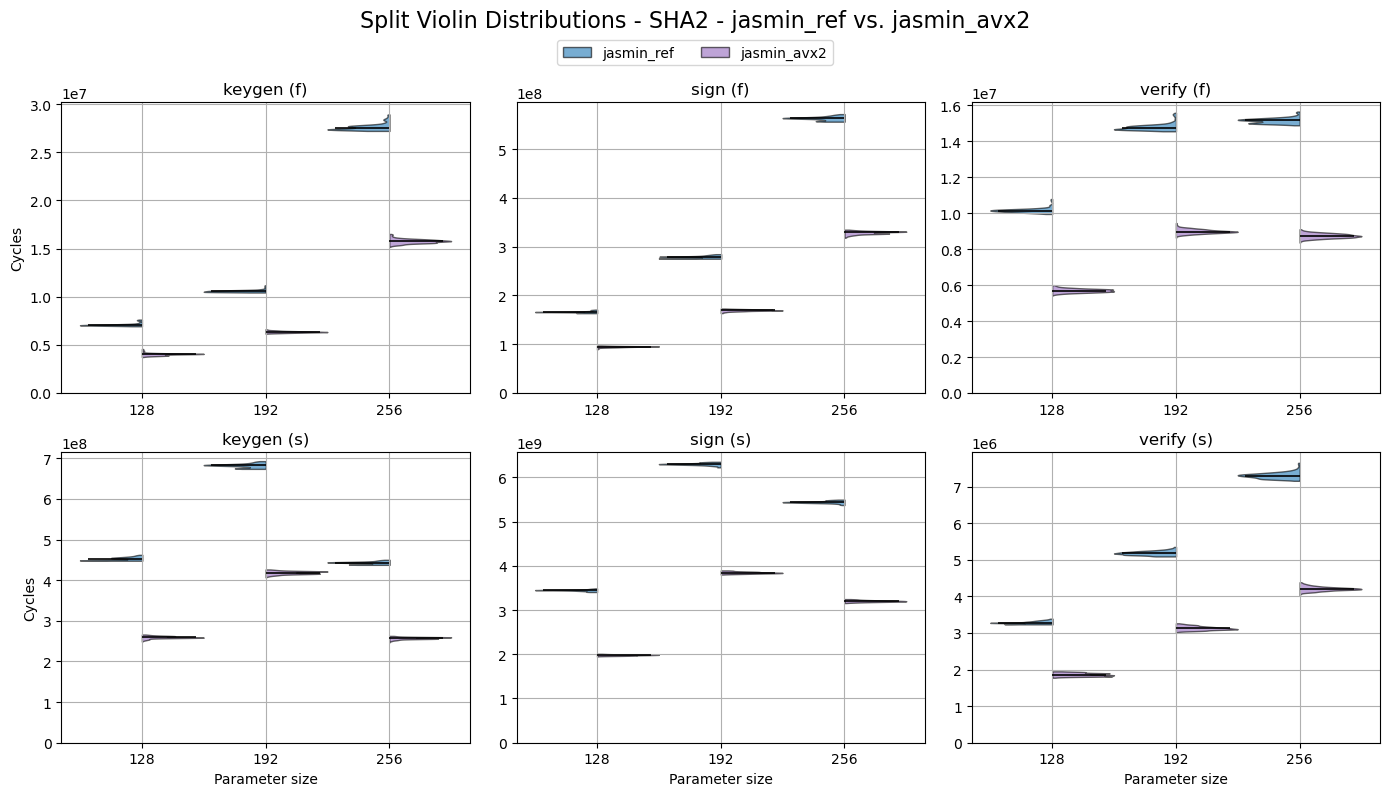

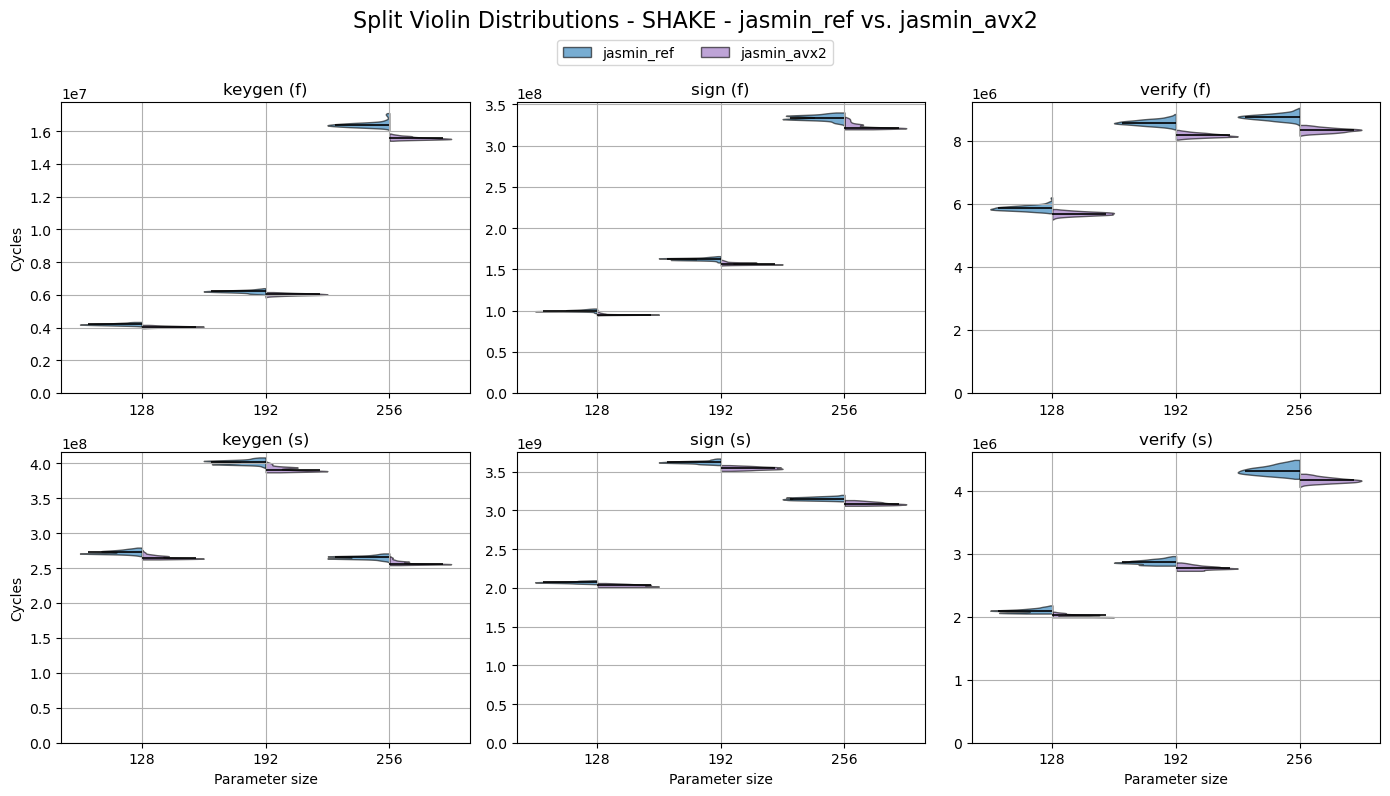

In [4]:
# visualise violin plot grid for SHA2 and SHAKE,
# comparing the Jasmin reference and AVX (optimised) implementations

plot_violin_grid(benchmark_data, "sha2", "jasmin_ref", "jasmin_avx2")
plot_violin_grid(benchmark_data, "shake", "jasmin_ref", "jasmin_avx2")

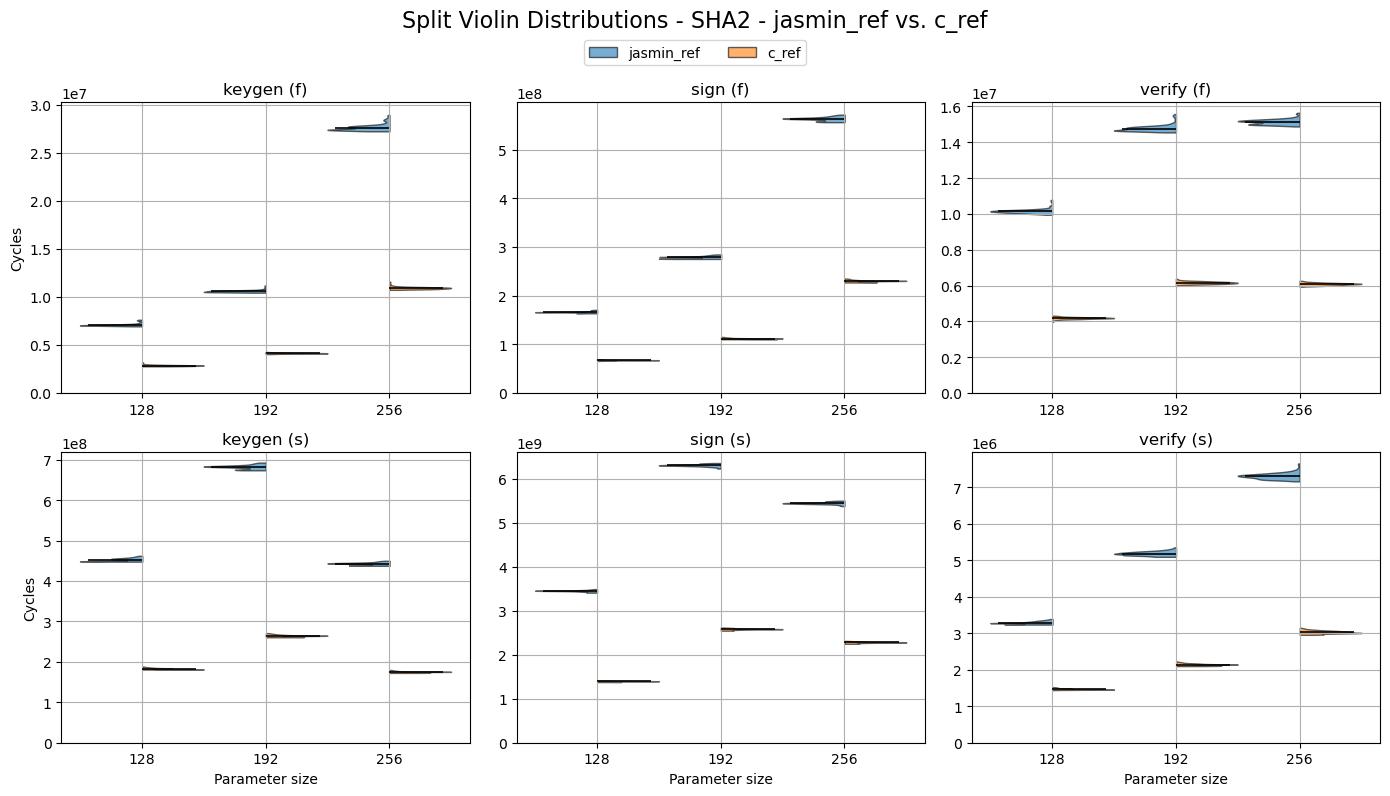

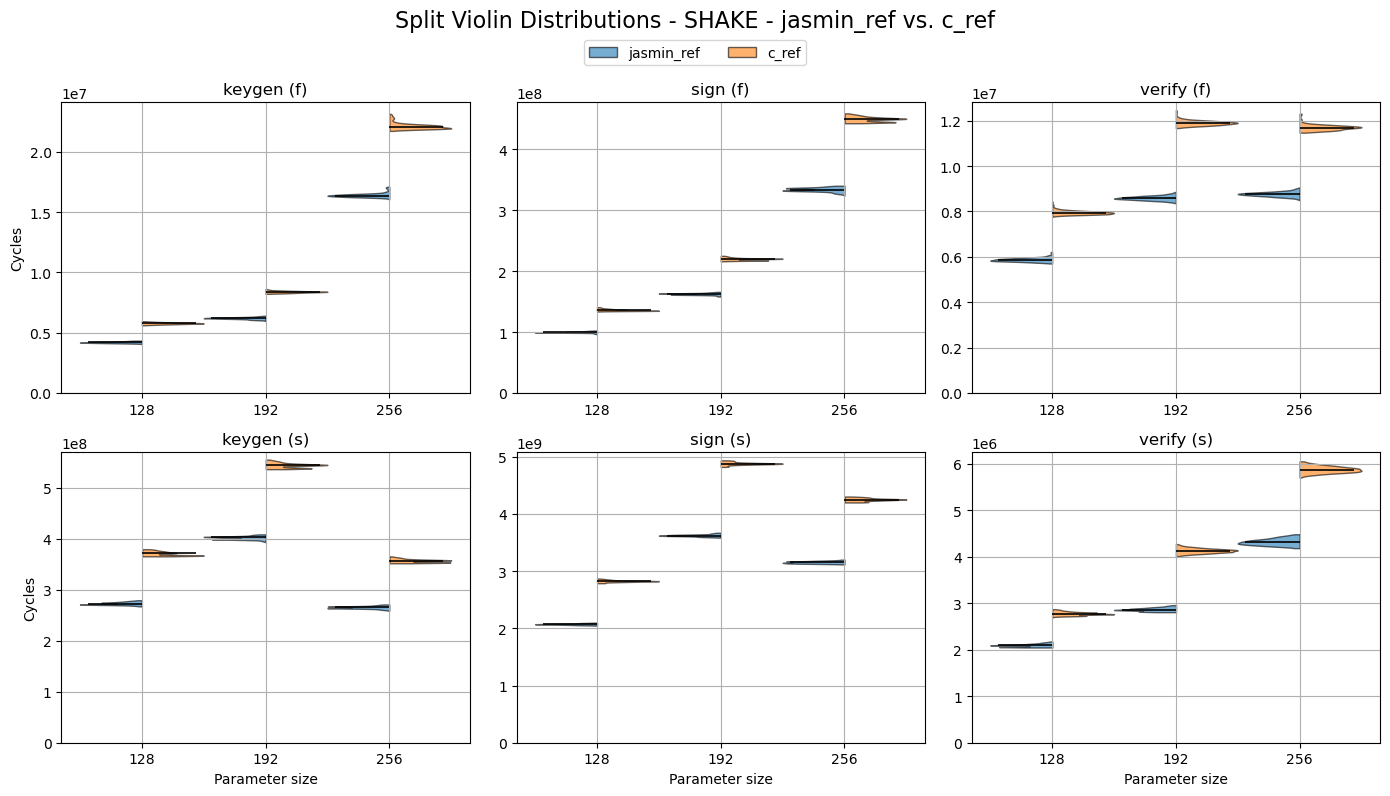

In [5]:
# visualise violin plot grid for SHA2 and SHAKE,
# comparing the Jasmin reference and C reference implementations

plot_violin_grid(benchmark_data, "sha2", "jasmin_ref", "c_ref")
plot_violin_grid(benchmark_data, "shake", "jasmin_ref", "c_ref")

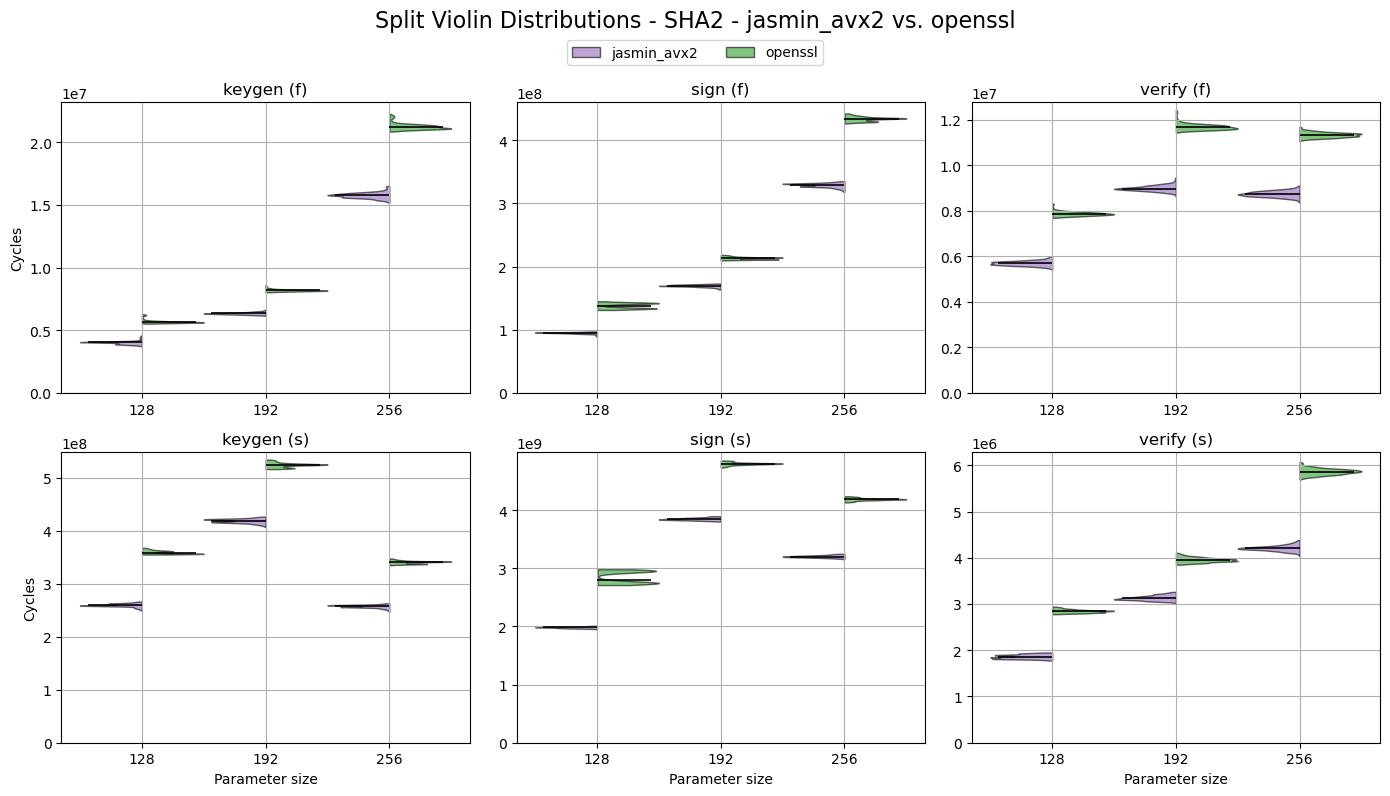

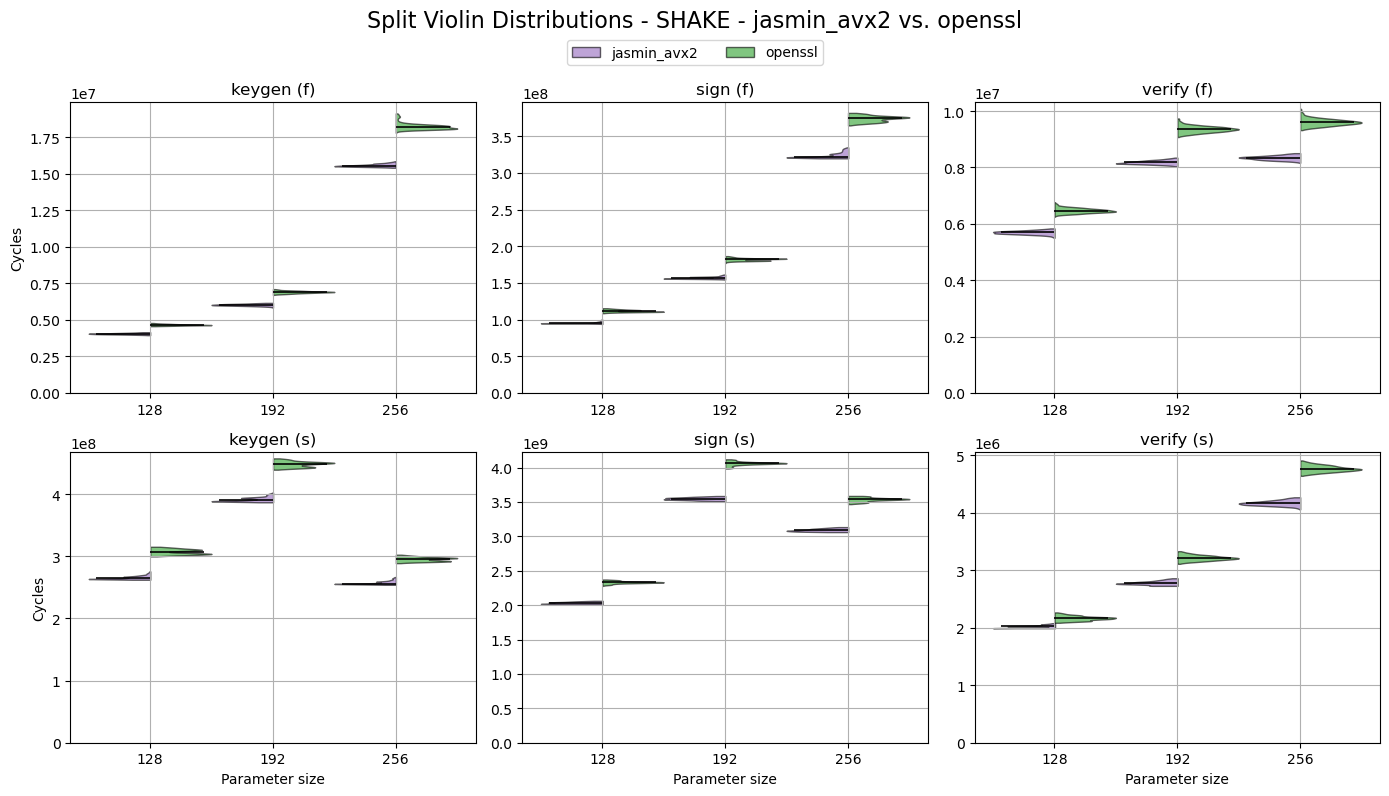

In [6]:
# visualise violin plot grid for SHA2 and SHAKE,
# comparing the Jasmin AVX2 (optimised) and OpenSSL implementations

plot_violin_grid(benchmark_data, "sha2", "jasmin_avx2", "openssl")
plot_violin_grid(benchmark_data, "shake", "jasmin_avx2", "openssl")